# Explainability pada Time Series Forecasting
## Reproduksi dari: [skforecast.org — Explainability](https://skforecast.org/0.15.1/user_guides/explainability.html)

---

## 📌 1. Analisa Prediksi Tentang Apa?

Tutorial ini melakukan **prediksi permintaan listrik harian (Electricity Demand)** di negara bagian **Victoria, Australia**.

- **Target (output)**: Total konsumsi listrik per hari dalam satuan **MW (Megawatt)**
- **Tujuan utama**: Bukan hanya meramalkan, tetapi **menjelaskan mengapa model membuat prediksi tersebut** (*explainability*)
- **Dataset**: `vic_electricity` — data setengah-jam dari 2012–2015, diagregasi menjadi **harian**

### Teknik Explainability yang digunakan:
| # | Metode | Scope |
|---|---|---|
| 1 | Feature Importance (LightGBM) | Global |
| 2 | SHAP Summary Plot | Global |
| 3 | SHAP Force Plot + Waterfall | **Lokal** (per prediksi) |
| 4 | SHAP Dependence Plot | Global |
| 5 | Permutation Importance | Global |
| 6 | Partial Dependence Plot (PDP) | Global |

---
## ⚙️ Instalasi Library

Jalankan cell berikut **sekali saja**, lalu **restart kernel** sebelum lanjut ke cell berikutnya.

In [1]:
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "skforecast", "lightgbm", "shap", "matplotlib", "pandas", "scikit-learn", "-q"
])
print("✅ Instalasi selesai! Silakan Restart Kernel (menu Kernel > Restart Kernel).")

✅ Instalasi selesai! Silakan Restart Kernel (menu Kernel > Restart Kernel).


---
## 📦 Import Library

| Library | Fungsi |
|---|---|
| `pandas` | Manipulasi dan analisis data tabular |
| `matplotlib` | Visualisasi grafik |
| `lightgbm` | Model gradient boosting berbasis tree |
| `skforecast` | Framework forecasting time series |
| `shap` | Menghitung dan memvisualisasikan SHAP values |
| `sklearn.inspection` | Permutation importance & Partial Dependence Plot |

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

import logging
logging.getLogger('lightgbm').setLevel(logging.ERROR)

print("✅ Semua library berhasil diimport!")
import skforecast
print(f"   skforecast : {skforecast.__version__}")
print(f"   shap       : {shap.__version__}")
import lightgbm
print(f"   lightgbm   : {lightgbm.__version__}")

✅ Semua library berhasil diimport!
   skforecast : 0.22.0
   shap       : 0.52.0
   lightgbm   : 4.6.0


---
## 📊 2. Bentuk Data Training

### Sumber Data
Dataset `vic_electricity` dari paket `tsibbledata` (R), berisi konsumsi listrik Victoria, Australia dengan frekuensi setengah-jam.

### Kolom setelah agregasi harian:
| Kolom | Peran | Keterangan |
|---|---|---|
| `Demand` | **Target (y)** | Total konsumsi listrik per hari (sum) |
| `Temperature` | **Fitur eksogen** | Suhu rata-rata per hari (mean) |

In [3]:
# Download dan load dataset
data = fetch_dataset(name="vic_electricity")
print(f"Shape data asli : {data.shape}")
print("\n5 baris pertama:")
print(data.head().to_string())

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

Shape data asli : (52608, 4)

5 baris pertama:
                          Demand  Temperature        Date  Holiday
Time                                                              
2011-12-31 13:00:00  4382.825174        21.40  2012-01-01     True
2011-12-31 13:30:00  4263.365526        21.05  2012-01-01     True
2011-12-31 14:00:00  4048.966046        20.70  2012-01-01     True
2011-12-31 14:30:00  3877.563330        20.55  2012-01-01     True
2011-12-31 15:00:00  4036.229746        20.40  2012-01-01     True


In [4]:
# Agregasi dari setengah-jam menjadi harian
# Demand  : dijumlahkan (total per hari)
# Temperature : dirata-ratakan (rata-rata per hari)
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})

print(f"Shape setelah agregasi : {data.shape}")
print(f"Periode data           : {data.index.min().date()} s.d. {data.index.max().date()}")
print("\n5 baris pertama:")
print(data.head().to_string())

Shape setelah agregasi : (1097, 2)
Periode data           : 2011-12-31 s.d. 2014-12-31

5 baris pertama:
                   Demand  Temperature
Time                                  
2011-12-31   82531.745918    21.047727
2012-01-01  227778.257304    26.578125
2012-01-02  275490.988882    31.751042
2012-01-03  258955.329422    24.567708
2012-01-04  213792.376946    18.191667


### Visualisasi Data Time Series

Plot di bawah menampilkan dua variabel utama:
- **Demand** — konsumsi listrik harian (target prediksi)
- **Temperature** — suhu rata-rata harian (fitur eksogen)

Terlihat pola musiman yang jelas: konsumsi naik saat suhu sangat tinggi (musim panas) maupun sangat rendah (musim dingin).

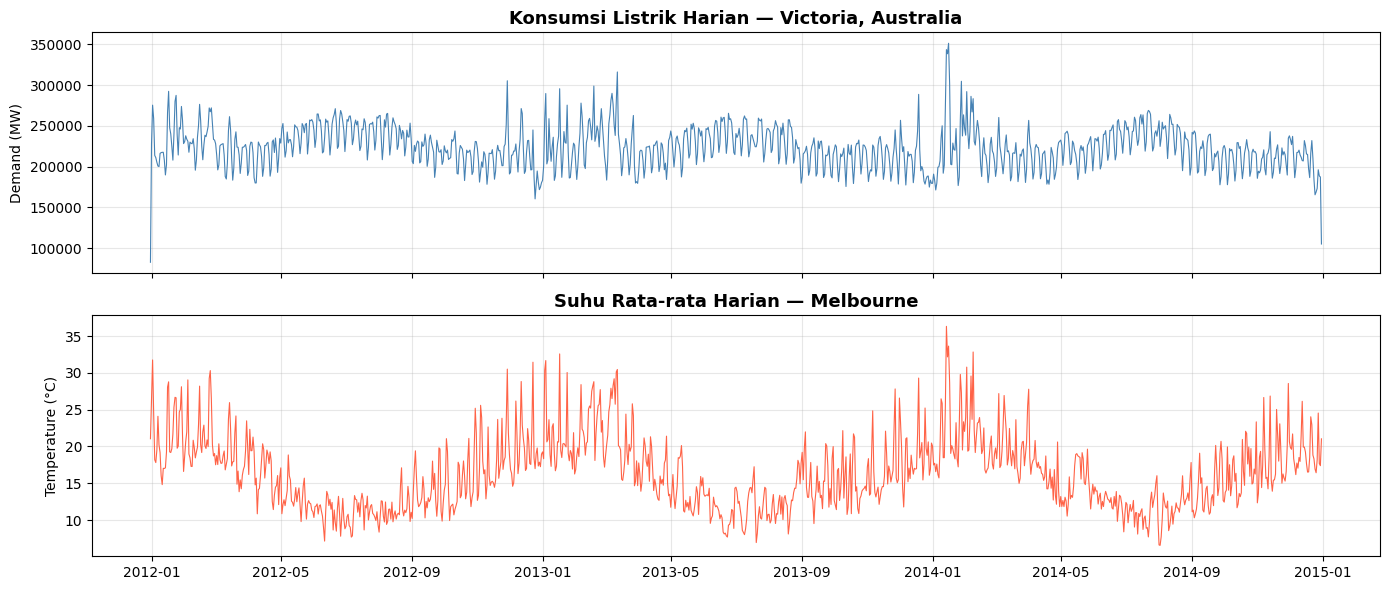

In [5]:
# Visualisasi time series
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(data.index, data['Demand'], color='steelblue', linewidth=0.8)
axes[0].set_title('Konsumsi Listrik Harian — Victoria, Australia', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(data.index, data['Temperature'], color='tomato', linewidth=0.8)
axes[1].set_title('Suhu Rata-rata Harian — Melbourne', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## ❓ 3. Apa Itu Lag?

**Lag** adalah nilai dari **waktu sebelumnya** yang dijadikan fitur input untuk memprediksi nilai saat ini.

Model ML seperti LightGBM **tidak mengerti urutan waktu** secara otomatis.  
Dengan lag, time series diubah menjadi **tabel regresi biasa** yang bisa diproses model.

### Ilustrasi `lags = 7`:
```
Hari ini (target) ← diprediksi dari:
  lag_1 = demand kemarin        (t-1)
  lag_2 = demand 2 hari lalu    (t-2)
  lag_3 = demand 3 hari lalu    (t-3)
  ...       ...
  lag_7 = demand 7 hari lalu    (t-7)
  + Temperature hari ini (eksogen)
```

### Bentuk matriks training setelah dibuat lag:
| lag_1 | lag_2 | ... | lag_7 | Temperature | **y (target)** |
|---|---|---|---|---|---|
| 205338 | 211066 | ... | 82531 | 24.09 | **200693** |
| 200693 | 205338 | ... | 227778 | 20.22 | **200061** |

---
## 🤖 Membuat dan Melatih Forecaster

`ForecasterRecursive` secara otomatis:
1. Membuat fitur lag dari time series
2. Melatih model LightGBM menggunakan fitur-fitur tersebut
3. Saat prediksi, output sebelumnya dipakai sebagai input (strategi rekursif)

In [6]:
# Buat dan latih forecaster
forecaster = ForecasterRecursive(
    estimator = LGBMRegressor(random_state=123, verbose=-1),
    lags      = 7
)

forecaster.fit(
    y    = data['Demand'],
    exog = data['Temperature']
)

print("✅ Forecaster berhasil dilatih!")
print(forecaster)

✅ Forecaster berhasil dilatih!
ForecasterRecursive 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-31 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq

In [7]:
# Buat matriks training (X_train, y_train)
X_train, y_train = forecaster.create_train_X_y(
    y    = data['Demand'],
    exog = data['Temperature']
)

print("=" * 55)
print("MATRIKS X_train (INPUT FITUR):")
print("=" * 55)
print(f"Shape  : {X_train.shape}  ({X_train.shape[0]} baris x {X_train.shape[1]} kolom)")
print(f"Kolom  : {X_train.columns.tolist()}")
print("\n5 baris pertama:")
print(X_train.head().to_string())
print("\n" + "=" * 55)
print("y_train (TARGET OUTPUT):")
print("=" * 55)
print(y_train.head().to_string())

MATRIKS X_train (INPUT FITUR):
Shape  : (1090, 8)  (1090 baris x 8 kolom)
Kolom  : ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'Temperature']

5 baris pertama:
                    lag_1          lag_2          lag_3          lag_4          lag_5          lag_6          lag_7  Temperature
Time                                                                                                                            
2012-01-07  205338.714620  211066.426550  213792.376946  258955.329422  275490.988882  227778.257304   82531.745918    24.098958
2012-01-08  200693.270298  205338.714620  211066.426550  213792.376946  258955.329422  275490.988882  227778.257304    20.223958
2012-01-09  200061.614738  200693.270298  205338.714620  211066.426550  213792.376946  258955.329422  275490.988882    19.161458
2012-01-10  216201.836844  200061.614738  200693.270298  205338.714620  211066.426550  213792.376946  258955.329422    16.042708
2012-01-11  217176.907910  216201.836844  2000

---
## 🧪 4. Proses Analisis Explainability

Ada **6 tahap** analisis untuk memahami perilaku model:

| Tahap | Metode | Pertanyaan yang dijawab |
|---|---|---|
| 1 | Feature Importance | Fitur mana yang paling sering dipakai model? |
| 2 | SHAP Summary Plot | Fitur mana yang paling berpengaruh & ke arah mana? |
| 3 | SHAP Force + Waterfall | Mengapa model membuat prediksi X pada tanggal Y? |
| 4 | SHAP Dependence Plot | Bagaimana hubungan fitur tertentu dengan prediksi? |
| 5 | Permutation Importance | Jika fitur ini diacak, seberapa buruk modelnya? |
| 6 | Partial Dependence Plot | Apa efek rata-rata fitur terhadap target? |

### 📊 Tahap 1: Model-Specific Feature Importance

LightGBM menghitung pentingnya fitur berdasarkan **berapa kali fitur digunakan untuk melakukan split**  
di semua decision tree dalam ensemble. Semakin sering dipakai = semakin penting.

skforecast menyediakan method `get_feature_importances()` untuk mengaksesnya langsung dari forecaster.

Feature Importance (diurutkan):
    feature  importance
Temperature         535
      lag_1         471
      lag_2         377
      lag_7         347
      lag_3         345
      lag_6         319
      lag_4         311
      lag_5         295


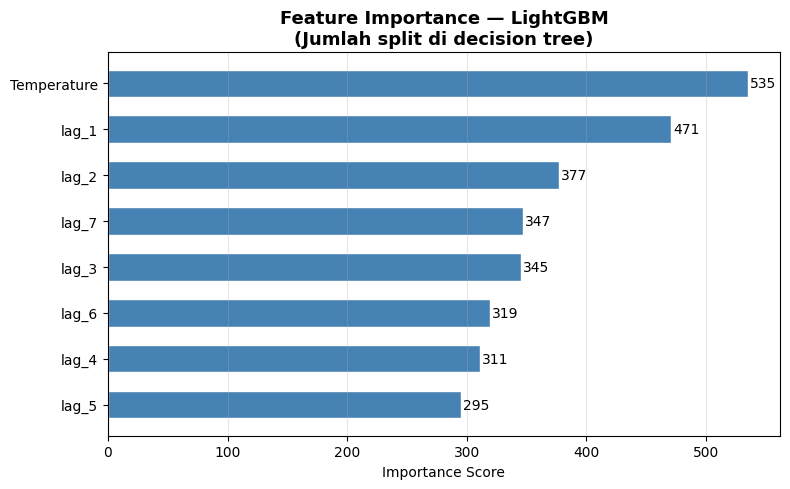

In [8]:
# Ambil feature importance dari forecaster
importance = forecaster.get_feature_importances()
importance_sorted = importance.sort_values('importance', ascending=False)

print("Feature Importance (diurutkan):")
print(importance_sorted.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 5))
imp_asc = importance_sorted.sort_values('importance', ascending=True)
bars = ax.barh(imp_asc['feature'], imp_asc['importance'],
               color='steelblue', edgecolor='white', height=0.6)
ax.set_title('Feature Importance — LightGBM\n(Jumlah split di decision tree)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, imp_asc['importance']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
### 📊 Tahap 2: SHAP Values — Summary Plot

**SHAP (SHapley Additive exPlanations)** berasal dari teori permainan kooperatif.  
SHAP menghitung **kontribusi marginal** setiap fitur terhadap prediksi.

#### Kelebihan SHAP vs Feature Importance biasa:
- Bisa global (semua data) maupun **lokal** (satu prediksi)
- Menampilkan **arah pengaruh** (positif = dorong naik, negatif = dorong turun)
- Konsisten secara matematis

#### Cara membaca SHAP Summary Plot:
- **Sumbu Y** → Fitur (diurutkan dari paling penting)
- **Sumbu X** → Nilai SHAP (positif = dorong prediksi naik, negatif = dorong turun)
- **Warna titik** → Nilai fitur (🔴 tinggi, 🔵 rendah)

Untuk model berbasis tree (LightGBM), digunakan **TreeExplainer** yang sangat efisien.

In [9]:
# Buat SHAP TreeExplainer menggunakan estimator internal forecaster
explainer   = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

print(f"Shape SHAP values : {shap_values.shape}")
print(f"Shape X_train     : {X_train.shape}")
print("Setiap baris = satu observasi, setiap kolom = nilai SHAP untuk satu fitur")

Shape SHAP values : (1090, 8)
Shape X_train     : (1090, 8)
Setiap baris = satu observasi, setiap kolom = nilai SHAP untuk satu fitur


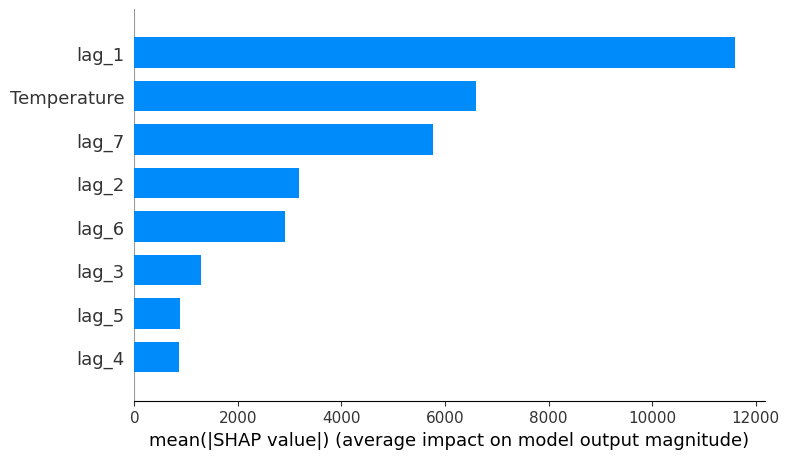

In [10]:
# SHAP Summary Plot — Bar chart (global importance)
# Menampilkan rata-rata |SHAP value| per fitur
shap.summary_plot(shap_values, X_train, plot_type="bar", show=True)

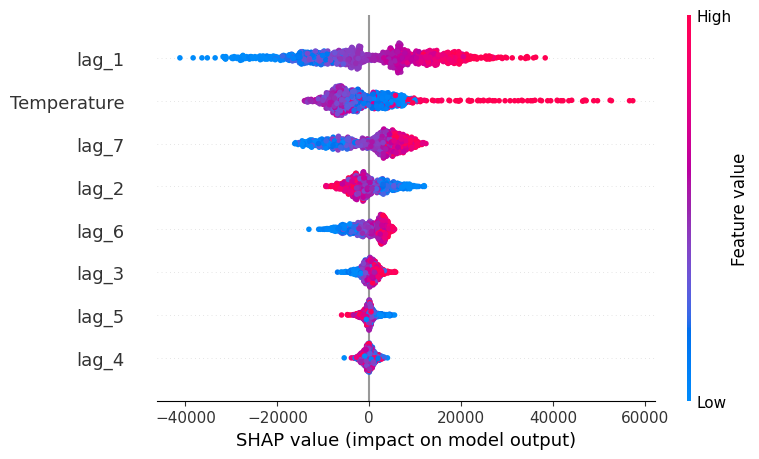

In [11]:
# SHAP Summary Plot — Beeswarm (distribusi + arah pengaruh)
# Setiap titik = satu observasi
# Warna merah = nilai fitur tinggi, biru = rendah
shap.summary_plot(shap_values, X_train, show=True)

---
### 📊 Tahap 3: SHAP Force Plot + Waterfall — Penjelasan Prediksi Individual

Berbeda dengan summary plot yang bersifat global, **Force Plot** dan **Waterfall Plot**  
menjelaskan **satu prediksi tertentu** secara detail (*local explanation*).

Cara membaca:
- **Base value (E[f(x)])** → Rata-rata prediksi model dari seluruh data training
- **f(x)** → Nilai prediksi akhir untuk observasi ini
- **Bar merah** → Fitur yang mendorong prediksi **naik** dari base value
- **Bar biru** → Fitur yang mendorong prediksi **turun** dari base value
- **Panjang bar** → Besarnya kontribusi fitur tersebut

Tanggal  : 2012-01-07
Base val : 223820 MW  (rata-rata prediksi model)
Prediksi : 207163 MW

Nilai fitur:
                   lag_1         lag_2          lag_3          lag_4          lag_5          lag_6         lag_7  Temperature
Time                                                                                                                         
2012-01-07  205338.71462  211066.42655  213792.376946  258955.329422  275490.988882  227778.257304  82531.745918    24.098958


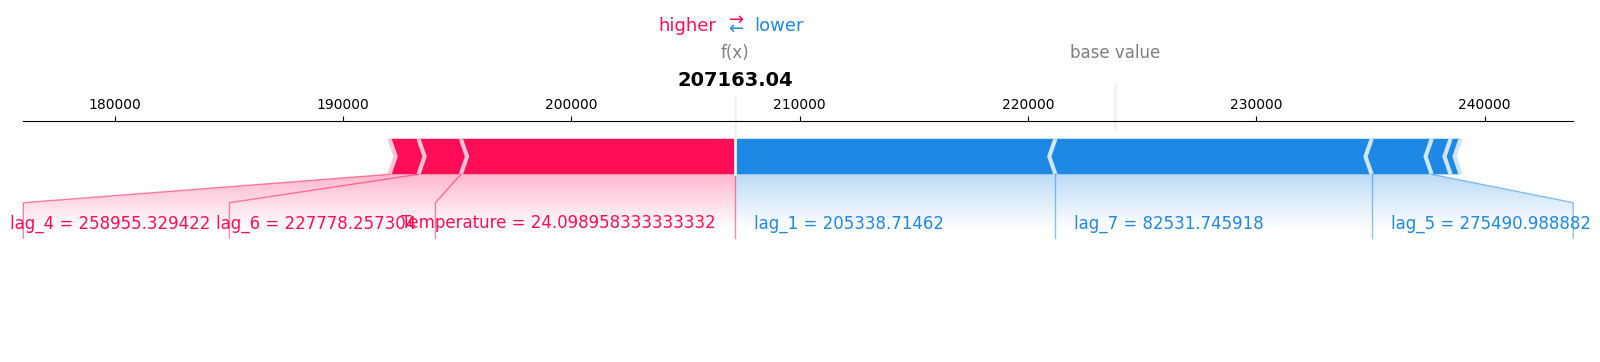

In [12]:
# Informasi observasi pertama
idx = 0
print(f"Tanggal  : {X_train.index[idx].date()}")
print(f"Base val : {explainer.expected_value:.0f} MW  (rata-rata prediksi model)")
print(f"Prediksi : {explainer.expected_value + shap_values[idx, :].sum():.0f} MW")
print("\nNilai fitur:")
print(X_train.iloc[[idx]].to_string())

# Force plot — matplotlib=True wajib untuk VSCode/Jupyter lokal
shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    X_train.iloc[idx, :],
    matplotlib = True,
    show       = True
)

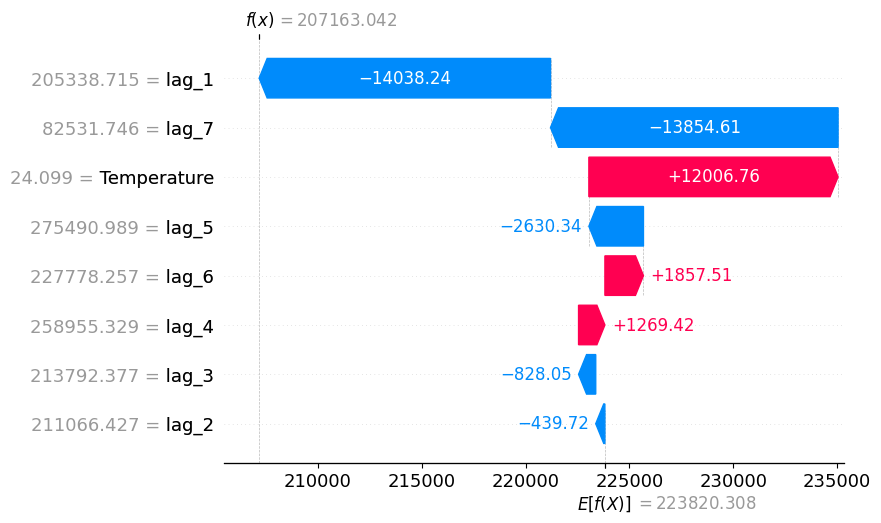

In [13]:
# Waterfall plot — tampilan alternatif yang lebih detail
# Menampilkan kontribusi tiap fitur secara bertumpuk (waterfall)
shap_exp = shap.Explanation(
    values        = shap_values[idx, :],
    base_values   = float(explainer.expected_value),
    data          = X_train.iloc[idx, :].values,
    feature_names = X_train.columns.tolist()
)

shap.waterfall_plot(shap_exp, show=True)

---
### 📊 Tahap 4: SHAP Dependence Plot

**SHAP Dependence Plot** menampilkan hubungan antara **nilai satu fitur** dengan **nilai SHAP-nya**  
(seberapa besar kontribusinya terhadap prediksi).

- **Sumbu X** → Nilai fitur yang dipilih
- **Sumbu Y** → Nilai SHAP (kontribusi positif/negatif terhadap prediksi)
- **Warna titik** → Nilai fitur lain yang paling berinteraksi (dipilih otomatis oleh SHAP)

Berguna untuk melihat apakah hubungan fitur-target bersifat **linear atau non-linear**.

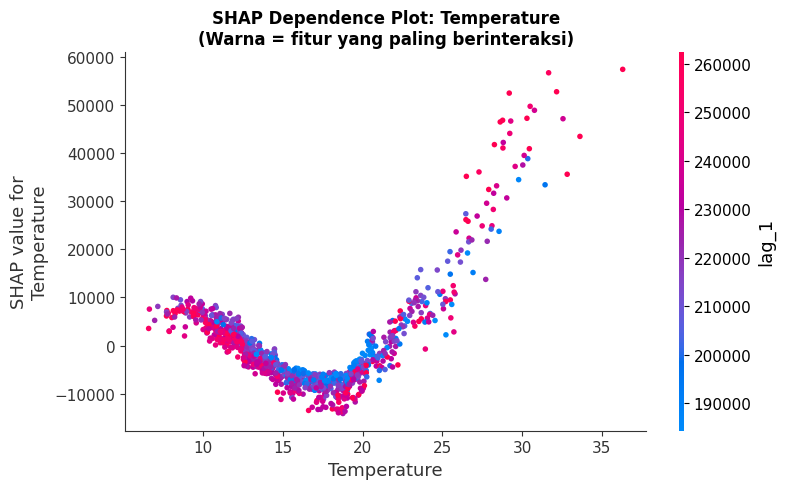

In [14]:
# SHAP Dependence Plot — Temperature
fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax, show=False)
ax.set_title("SHAP Dependence Plot: Temperature\n(Warna = fitur yang paling berinteraksi)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

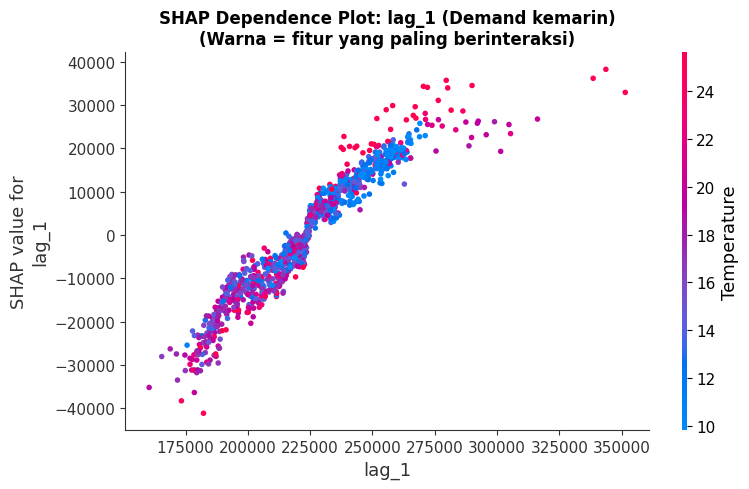

In [15]:
# SHAP Dependence Plot — lag_1 (demand kemarin)
fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot("lag_1", shap_values, X_train, ax=ax, show=False)
ax.set_title("SHAP Dependence Plot: lag_1 (Demand kemarin)\n(Warna = fitur yang paling berinteraksi)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 📊 Tahap 5: Permutation Feature Importance

Metode **model-agnostik** yang mengukur pentingnya fitur dengan cara:
1. Latih model → catat error baseline (R²)
2. **Acak (shuffle) nilai satu fitur** secara random
3. Hitung peningkatan error setelah diacak
4. Selisih error = kepentingan fitur tersebut

$$I_i = \text{Error}_{\text{permuted}(i)} - \text{Error}_{\text{original}}$$

| | Feature Importance | Permutation Importance |
|---|---|---|
| Basis | Struktur tree | Perubahan performa model |
| Model-agnostik | ❌ | ✅ |
| Bias fitur banyak nilai unik | Ya | Tidak |

In [16]:
# Hitung Permutation Importance
result = permutation_importance(
    estimator    = forecaster.estimator,
    X            = X_train,
    y            = y_train,
    n_repeats    = 5,
    random_state = 123,
    n_jobs       = -1
)

perm_df = pd.DataFrame({
    'feature'        : X_train.columns,
    'importance_mean': result.importances_mean,
    'importance_std' : result.importances_std
}).sort_values('importance_mean', ascending=False)

print("Permutation Importance (diurutkan):")
print(perm_df.to_string(index=False))

Permutation Importance (diurutkan):
    feature  importance_mean  importance_std
      lag_1         0.671814        0.044623
Temperature         0.382056        0.014953
      lag_7         0.186175        0.005599
      lag_2         0.113051        0.004446
      lag_6         0.076533        0.004470
      lag_3         0.037839        0.002577
      lag_5         0.028941        0.001968
      lag_4         0.027186        0.000723


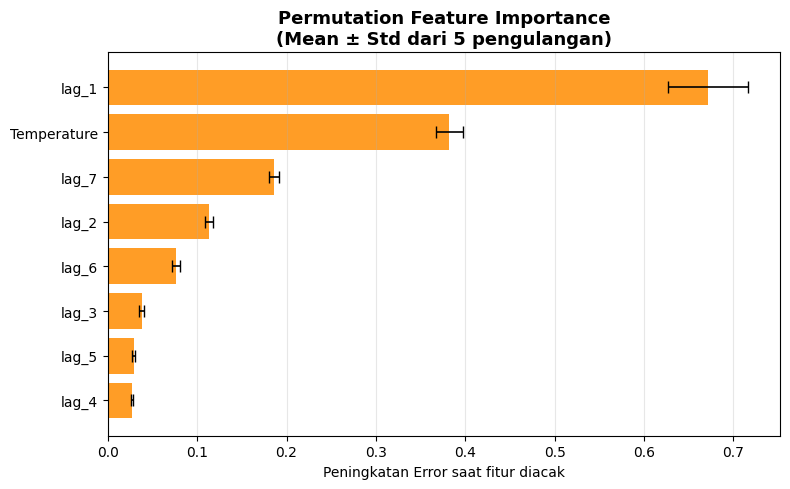

In [17]:
# Visualisasi Permutation Importance dengan error bar
fig, ax = plt.subplots(figsize=(8, 5))
sorted_df = perm_df.sort_values('importance_mean', ascending=True)
ax.barh(
    sorted_df['feature'],
    sorted_df['importance_mean'],
    xerr     = sorted_df['importance_std'],
    color    = 'darkorange',
    alpha    = 0.85,
    error_kw = dict(ecolor='black', capsize=4, linewidth=1.2)
)
ax.set_title('Permutation Feature Importance\n(Mean ± Std dari 5 pengulangan)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Peningkatan Error saat fitur diacak')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
### 📊 Tahap 6: Partial Dependence Plot (PDP)

**PDP** menampilkan efek **rata-rata** satu fitur terhadap prediksi,  
dengan cara memarginalisasi (merata-ratakan) pengaruh semua fitur lainnya.

- **Garis tebal (biru)** → Rata-rata efek fitur terhadap prediksi (PDP)
- **Garis tipis (abu)** → Efek per observasi individual (ICE — Individual Conditional Expectation)

Jika garis ICE berbeda-beda arahnya = ada **interaksi antar fitur** yang signifikan.

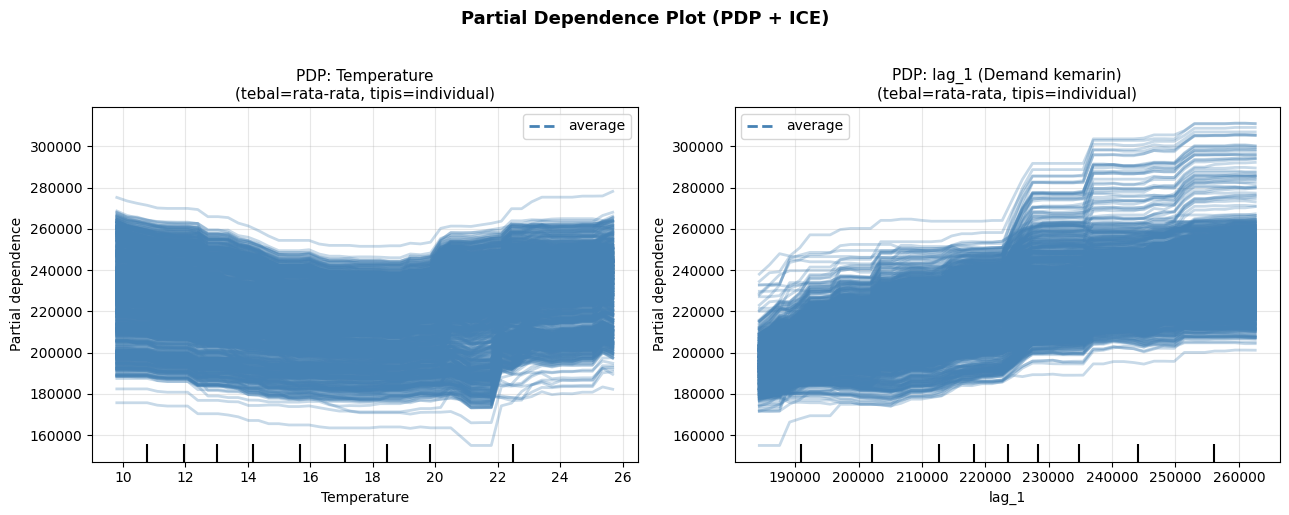

In [18]:
# Partial Dependence Plot untuk Temperature dan lag_1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

PartialDependenceDisplay.from_estimator(
    estimator       = forecaster.estimator,
    X               = X_train,
    features        = ["Temperature", "lag_1"],
    kind            = 'both',
    ax              = axes,
    grid_resolution = 50,
    line_kw         = {"color": "steelblue", "linewidth": 2}
)

axes[0].set_title('PDP: Temperature\n(tebal=rata-rata, tipis=individual)', fontsize=11)
axes[1].set_title('PDP: lag_1 (Demand kemarin)\n(tebal=rata-rata, tipis=individual)', fontsize=11)
for ax in axes:
    ax.grid(True, alpha=0.3)

plt.suptitle('Partial Dependence Plot (PDP + ICE)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## ✅ Ringkasan Temuan Analisis

### Fitur Paling Penting

| Fitur | Kepentingan | Alasan |
|---|---|---|
| **Temperature** | ⭐⭐⭐ Terbesar | Suhu dingin → pemanas, suhu panas → AC |
| **lag_1** | ⭐⭐ | Demand kemarin sangat relevan (momentum harian) |
| **lag_7** | ⭐ | Pola mingguan (hari kerja vs akhir pekan) |

### Insight dari Tiap Metode:
1. **Feature Importance** → Temperature dan lag_1 mendominasi jumlah split
2. **SHAP Beeswarm** → Temperature tinggi (merah) → SHAP positif (dorong prediksi naik)
3. **Force/Waterfall Plot** → Per prediksi bisa dilihat fitur mana yang paling menentukan
4. **Dependence Plot** → Hubungan Temperature–Demand berbentuk **U** (non-linear)
5. **Permutation Importance** → Konsisten dengan SHAP: Temperature paling krusial
6. **PDP** → Semakin tinggi lag_1 → semakin tinggi prediksi demand

---

## 📚 Kesimpulan

> **Explainability** bukan hanya nilai akademis — dalam aplikasi nyata (energi, kesehatan, keuangan),  
> memahami *mengapa* model membuat prediksi tertentu adalah krusial untuk **kepercayaan dan pengambilan keputusan**.

| Metode | Scope | Kelebihan Utama |
|---|---|---|
| Feature Importance | Global | Cepat, bawaan model |
| Permutation Importance | Global | Model-agnostik, lebih objektif |
| SHAP Summary (bar) | Global | Rata-rata kontribusi absolut |
| SHAP Beeswarm | Global | Arah + distribusi pengaruh |
| SHAP Force/Waterfall | **Lokal** | Penjelasan per-prediksi individual |
| SHAP Dependence | Global | Non-linearitas + interaksi antar fitur |
| PDP + ICE | Global | Efek marginal fitur terhadap target |